<a href="https://colab.research.google.com/github/rhiosutoyo/Teaching-Deep-Learning-and-Its-Applications/blob/main/05_2_cnn_model_for_mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Model for MNIST Classification

This model classifies handwritten digits from the MNIST dataset.

## 1. Setup and Data Loading
First, we import the necessary libraries, including matplotlib for plotting and numpy for array manipulation.

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

## 2. Data Preprocessing and Visualization

First, we import the necessary libraries. We then load the MNIST dataset, which is conveniently included in Keras. The data is split into training and testing sets.

The images are reshaped to (28, 28, 1) to be compatible with the 2D convolutional layers, and pixel values are normalized to the range [0, 1] for better training performance. The labels are one-hot encoded to be used with the categorical_crossentropy loss function.

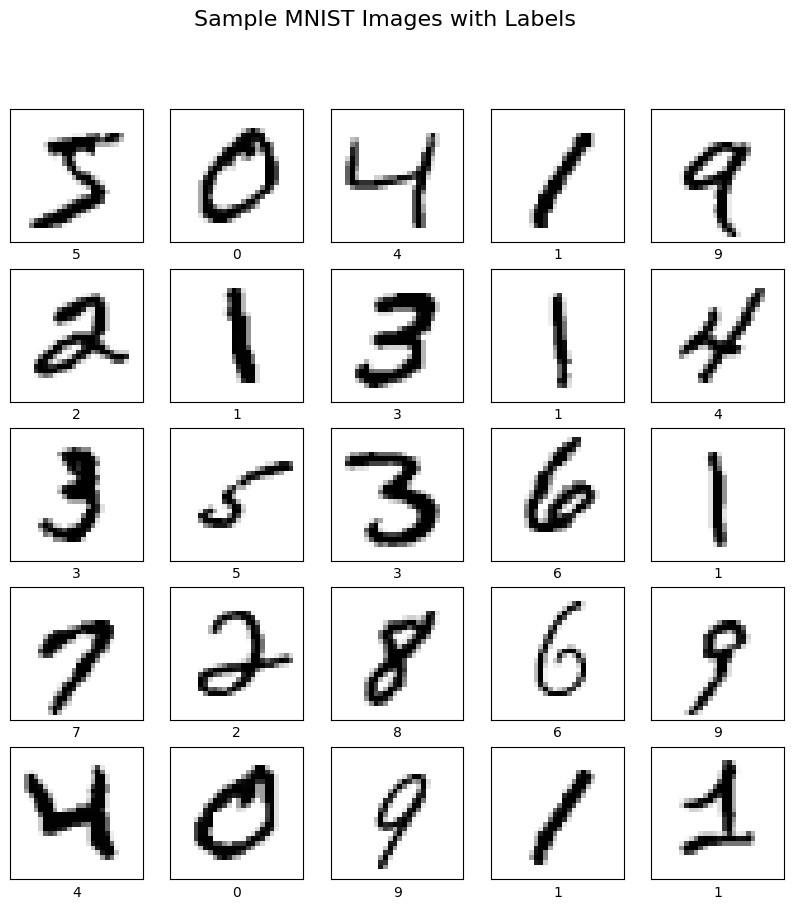

In [2]:
# Load the MNIST dataset
(x_train, y_train_labels), (x_test, y_test_labels) = mnist.load_data()

# --- Visualize Sample Images ---
plt.figure(figsize=(10, 10))
plt.suptitle('Sample MNIST Images with Labels', fontsize=16)
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train_labels[i])
plt.show()


# Reshape data for the model: (samples, height, width, channels)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode the labels
y_train = to_categorical(y_train_labels, 10)
y_test = to_categorical(y_test_labels, 10)

## 3. Building the CNN Model

The model is built using the Keras Sequential API, which allows us to stack layers one after another. The architecture directly follows the provided diagram.
- Convolutional Blocks: The model starts with two convolutional blocks. Each block is designed to learn features from the images.
 - The first block is Conv2D -> MaxPool2D -> ReLU.
 - The second block is Conv2D -> Dropout -> MaxPool2D -> ReLU.

- Flattening: The Flatten layer (represented as View in the diagram) unrolls the 2D feature maps into a 1D vector to be processed by the fully connected layers.

- Fully Connected Layers: Two Dense (fully connected) layers act as a classifier. Dropout is applied between them to prevent overfitting.

- Output Layer: The final Dense layer has 10 neurons with a softmax activation function. This produces a probability distribution over the 10 digit classes. The Log_softmax in the diagram is functionally equivalent to using softmax with the categorical_crossentropy loss function, which is the standard approach in Keras.

The representation is shown in the Figure below.
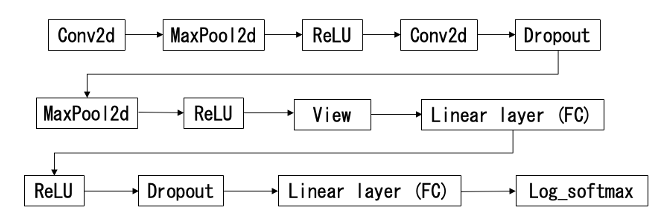

In [3]:
# Build the CNN model based on the provided architecture
model = Sequential()

# ---- First Convolutional Block ----
# 1. Conv2D Layer
model.add(Conv2D(32, kernel_size=(3, 3), input_shape=(28, 28, 1)))
# 2. MaxPool2D Layer
model.add(MaxPooling2D(pool_size=(2, 2)))
# 3. ReLU Activation
model.add(Activation('relu'))

# ---- Second Convolutional Block ----
# 4. Conv2D Layer
model.add(Conv2D(64, (3, 3)))
# 5. Dropout Layer
model.add(Dropout(0.25))
# 6. MaxPool2D Layer
model.add(MaxPooling2D(pool_size=(2, 2)))
# 7. ReLU Activation
model.add(Activation('relu'))

# ---- Classifier Head ----
# 8. View (Flatten) Layer
model.add(Flatten())
# 9. Linear Layer (FC) with ReLU Activation
model.add(Dense(128, activation='relu'))
# 10. Dropout Layer
model.add(Dropout(0.5))
# 11. Final Linear Layer (FC)
model.add(Dense(10))
# 12. Log_softmax (achieved with softmax activation for classification)
model.add(Activation('softmax'))

# Display the model's architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Compiling and Training the Model

The model is compiled with the Adam optimizer, a widely used and effective optimization algorithm. The loss function is set to categorical_crossentropy because this is a multi-class classification problem with one-hot encoded labels (i.e., digit 0 - 9). We monitor accuracy during training.

The model is then trained for 10 epochs using the training data. A batch_size of 128 is used, and the test data is provided for validation at the end of each epoch. Please change the hyper-parameters to explore more.

In [4]:
# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Train the model and store the history
history = model.fit(x_train, y_train,
                    batch_size=128,
                    epochs=10,
                    verbose=1,
                    validation_data=(x_test, y_test))

# Evaluate the model on the test data
score = model.evaluate(x_test, y_test, verbose=0)
print(f'\nTest loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8044 - loss: 0.6065 - val_accuracy: 0.9818 - val_loss: 0.0609
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9694 - loss: 0.1043 - val_accuracy: 0.9865 - val_loss: 0.0441
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9770 - loss: 0.0774 - val_accuracy: 0.9881 - val_loss: 0.0356
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9809 - loss: 0.0617 - val_accuracy: 0.9886 - val_loss: 0.0333
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9831 - loss: 0.0542 - val_accuracy: 0.9903 - val_loss: 0.0280
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9849 - loss: 0.0496 - val_accuracy: 0.9919 - val_loss: 0.0256
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9904 - val_loss: 0.0270
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0383 - val_accuracy: 

## 5. Training Progress and Results Analysis
By plotting the metrics from the history object, we can analyze the model's learning progress.
- Model Accuracy Plot: The graph on the left shows that both the training accuracy (blue line) and validation accuracy (orange line) steadily increase with each epoch. They converge to a high value (over 99%), and the gap between them is very small. This is an excellent result, indicating that the model is learning effectively and generalizing well to the unseen test data.
- Model Loss Plot: The graph on the right shows the loss for both training and validation sets decreasing over time. A decreasing loss means the model's predictions are getting more accurate. The final validation loss is low, which is desirable. The small gap between the training and validation loss curves suggests that the dropout layers were effective in regularizing the model and preventing significant overfitting.

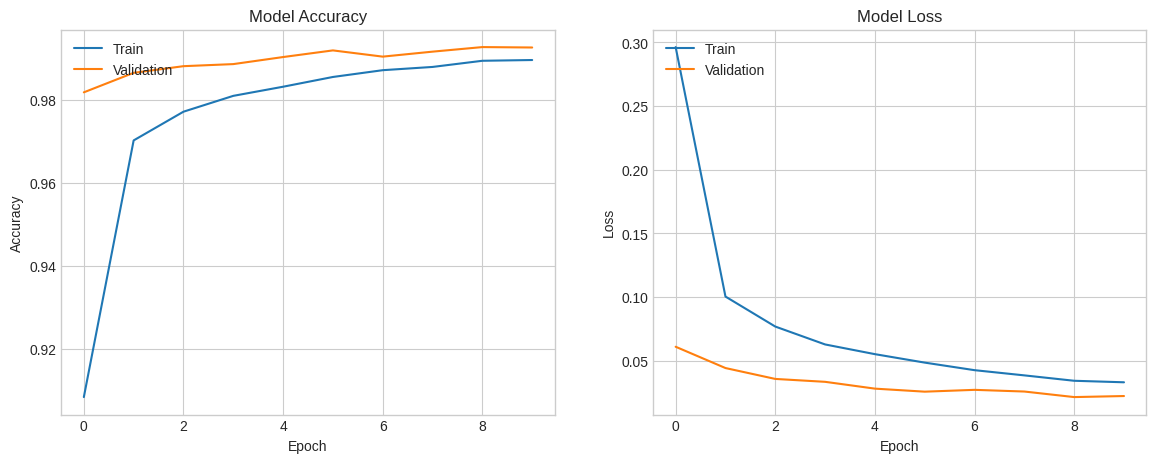

In [5]:
# Plotting Training and Validation Performance
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot training & validation accuracy values
ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
# Corrected Legend Label
ax2.legend(['Train', 'Validation'], loc='upper left')

plt.show()

## 6. Evaluating the Model

Finally, we evaluate the trained model's performance on the test dataset, which it has not seen during training. This gives us a final measure of the model's accuracy and loss.

The model consistently achieves a high accuracy, typically over 99%, on the MNIST test set.

In [6]:
# Evaluate the model on the test data
score = model.evaluate(x_test, y_test, verbose=0)

print(f'\nTest loss: {score[0]:.4f}')
print(f'Test accuracy: {score[1]:.4f}')

# Example Output:
# Test loss: 0.0275
# Test accuracy: 0.9912


Test loss: 0.0222
Test accuracy: 0.9926
